In [307]:
import numpy as np
import pandas as pd
import sklearn
import sklearn.linear_model
import seaborn as sns
from matplotlib import pyplot as plt

### Load Data

In [ ]:
data_path = "./data/3000_listings_with_scoring_v2";

# image_df = pd.read_csv(f"{data_path}/images_cleaned.csv")
# image_df.columns

listing_df = pd.read_csv(f"{data_path}/listings_with_scores.csv")

# preview dataframe
listing_df.head()

,level_0,source_id,url,price_man_yen,area_sqm,year_built,floor_number,floors_total,address,nearest_station,...,brightness_bathroom,brightness_bedroom,brightness_kitchen,brightness_living_room,brightness_toilet,condition_bathroom,condition_bedroom,condition_kitchen,condition_living_room,condition_toilet
0,1,20277732,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_2...,2390.0,52.89,1989,4.0,4.0,東京都足立区六月１ [ ■ 周辺環境 ],竹ノ塚駅,...,0.858398,0.320312,0.873047,NaN,0.878906,0.927734,0.707031,0.970703,NaN,0.851562
1,2,20332918,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_2...,1580.0,29.16,1976,6.0,9.0,東京都足立区東和５ [ ■ 周辺環境 ],北綾瀬駅,...,0.650391,0.685547,0.655273,NaN,0.925781,0.970703,0.971680,0.872070,NaN,0.652344
2,3,20344616,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_2...,2380.0,53.04,1974,3.0,8.0,東京都足立区梅田７-22-9 [ ■ 周辺環境 ],梅島駅,...,0.226562,0.724609,0.851562,NaN,0.906250,0.863281,0.902344,0.980469,NaN,0.914062
3,4,78385243,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_7...,1700.0,40.10,1985,1.0,5.0,東京都足立区青井１-16-9 [ ■ 周辺環境 ],青井駅,...,0.411458,0.798828,NaN,NaN,NaN,0.868490,0.955078,NaN,NaN,NaN
4,5,78151350,https://suumo.jp/ms/chuko/tokyo/sc_bunkyo/nc_7...,1800.0,26.29,1977,5.0,5.0,東京都文京区小石川５ [ ■ 周辺環境 ],茗荷谷駅,...,0.320312,0.226562,0.396484,NaN,NaN,0.919922,0.941406,0.990234,NaN,NaN


### Compute Distance to Shibuya

In [309]:
from geopy.distance import geodesic, great_circle

# Define coordinates for two locations as tuples (latitude, longitude)
# Example: Kolkata, India and Delhi, India
coords_kolkata = (22.5726, 88.3639)
coords_delhi = (28.7041, 77.1025)

# Calculate the distance
distance_geodesic = geodesic(coords_kolkata, coords_delhi)
distance_great_circle = great_circle(coords_kolkata, coords_delhi)

# Print the distance in various units
print(f"Geodesic distance: {distance_geodesic.km} kilometers")
print(f"Geodesic distance: {distance_geodesic.miles} miles")
print(f"Great-circle distance: {distance_great_circle.km} kilometers")

Geodesic distance: 1318.13891581683 kilometers
Geodesic distance: 819.0535496555303 miles
Great-circle distance: 1317.7554645657162 kilometers


In [ ]:
import geopandas
import geopandas.tools

# def compute_nearest_station_loc(row):
#   if "nearest_station_point" not in row:
#     location = geopandas.tools.geocode(row["nearest_station"])
#     row["nearest_station_point"] = location
    
#   if row.name % 10 == 0:
#     print(row.name, row["nearest_station"], row["nearest_station_point"].to_string())

#   return row;

# listing_df = listing_df.apply(compute_nearest_station_loc, axis=1)

# locations = geopandas.tools.geocode(listing_df["nearest_station"])

unique_stations = listing_df["nearest_station"].unique()

stations_df = pd.read_csv(station_locations)

# stations_df = pd.DataFrame()
# stations_df["station"] = unique_stations

# def geocode_station(row):
#   row["point"] = geopandas.tools.geocode(row["station"])

#   if row.name % 10 == 0:
#     print(row.name, row["point"])
  
#   return row

# stations_df_with_point = stations_df.apply(geocode_station, axis=1)

0                      geometry                             address
0  POINT (139.79078 35.79448)  竹ノ塚, 赤山街道, 121-0822, 赤山街道, 東京都, 日本
10                      geometry                                 address
0  POINT (139.66343 35.71953)  沼袋駅, 平和公園通り, 165-0025, 平和公園通り, 東京都, 日本
20                      geometry                               address
0  POINT (139.82408 35.76190)  綾瀬駅, 綾瀬川通り, 120-0005, 綾瀬川通り, 東京都, 日本
30                      geometry                              address
0  POINT (139.62382 35.64740)  千歳船橋, 城山通り, 156-8799, 城山通り, 東京都, 日本
40                      geometry                               address
0  POINT (139.87520 35.75657)  柴又駅, 帝釈天参道, 125-0052, 帝釈天参道, 東京都, 日本
50                      geometry                               address
0  POINT (139.67292 35.78705)  西台駅, メトロード, 174-0046, メトロード, 東京都, 日本
60                      geometry                              address
0  POINT (139.81178 35.74401)  京成関屋, 墨堤通り, 120-0023, 墨堤通り, 東京都, 日本
70                      geometry

In [346]:
stations_df_with_point[["station", "x", "y"]].to_csv("./station_locations.csv")

In [349]:
def attach_coords(row):
  coords = row["point"].get_coordinates()
  row["x"] = coords.loc[0, "x"]
  row["y"] = coords.loc[0, "y"]
  return row

stations_df_with_point = stations_df_with_point.apply(attach_coords, axis=1)
stations_df_with_point

,station,point,coords,x,y
0,竹ノ塚駅,geometry ...,x y 0 139.790777 35.79448,139.790777,35.794480
1,北綾瀬駅,geometry ...,x y 0 139.831318 35.777781,139.831318,35.777781
2,梅島駅,geometry ...,x y 0 139.79863 35.772872,139.798630,35.772872
3,青井駅,geometry ...,x y 0 139.820014 35.77224,139.820014,35.772240
4,茗荷谷駅,geometry ...,x y 0 139.73694 35.71719,139.736940,35.717190
...,...,...,...,...,...
387,東北沢駅,geometry ...,x y 0 139.673536 35.665731,139.673536,35.665731
388,国立競技場駅,geometry ...,x y 0 139.713514 35.67786,139.713514,35.677860
389,溜池山王駅,geometry ...,x y 0 139.741424 35.67299,139.741424,35.672990
390,北参道駅,geometry ...,x y 0 139.705169 35.67919,139.705169,35.679190


In [385]:
shibuya = stations_df_with_point[stations_df_with_point.station == "渋谷駅"].iloc[0,:]
shibuya_coords = shibuya[["x", "y"]]

stations_df_with_point["dist2_shibuya"] = stations_df_with_point["coords"].map(lambda coords: ((coords - shibuya_coords)**2).sum(axis=1).loc[0])

In [386]:
stations_df_with_point

,station,point,coords,x,y,dist2_shibuya
0,竹ノ塚駅,geometry ...,x y 0 139.790777 35.79448,139.790777,35.794480,0.026361
1,北綾瀬駅,geometry ...,x y 0 139.831318 35.777781,139.831318,35.777781,0.031089
2,梅島駅,geometry ...,x y 0 139.79863 35.772872,139.798630,35.772872,0.022473
3,青井駅,geometry ...,x y 0 139.820014 35.77224,139.820014,35.772240,0.026981
4,茗荷谷駅,geometry ...,x y 0 139.73694 35.71719,139.736940,35.717190,0.004653
...,...,...,...,...,...,...
387,東北沢駅,geometry ...,x y 0 139.673536 35.665731,139.673536,35.665731,0.000770
388,国立競技場駅,geometry ...,x y 0 139.713514 35.67786,139.713514,35.677860,0.000505
389,溜池山王駅,geometry ...,x y 0 139.741424 35.67299,139.741424,35.672990,0.001851
390,北参道駅,geometry ...,x y 0 139.705169 35.67919,139.705169,35.679190,0.000410


In [400]:
def lookup_dist(row):
  return stations_df_with_point[stations_df_with_point["station"] == row["nearest_station"]].iloc[0,:]["dist2_shibuya"]

listing_df["dist2_shibuya"] = listing_df.apply(lookup_dist, axis=1)
listing_df["dist_shibuya"] = np.clip(np.sqrt(listing_df["dist2_shibuya"]), -1, 0.25)

listing_df

,level_0,source_id,url,price_man_yen,area_sqm,year_built,floor_number,floors_total,address,nearest_station,...,brightness_kitchen,brightness_living_room,brightness_toilet,condition_bathroom,condition_bedroom,condition_kitchen,condition_living_room,condition_toilet,dist2_shibuya,dist_shibuya
0,1,20277732,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_2...,2390.0,52.89,1989,4.0,4.0,東京都足立区六月１ [ ■ 周辺環境 ],竹ノ塚駅,...,0.873047,NaN,0.878906,0.927734,0.707031,0.970703,NaN,0.851562,0.026361,0.162361
1,2,20332918,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_2...,1580.0,29.16,1976,6.0,9.0,東京都足立区東和５ [ ■ 周辺環境 ],北綾瀬駅,...,0.655273,NaN,0.925781,0.970703,0.971680,0.872070,NaN,0.652344,0.031089,0.176321
2,3,20344616,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_2...,2380.0,53.04,1974,3.0,8.0,東京都足立区梅田７-22-9 [ ■ 周辺環境 ],梅島駅,...,0.851562,NaN,0.906250,0.863281,0.902344,0.980469,NaN,0.914062,0.022473,0.149909
3,4,78385243,https://suumo.jp/ms/chuko/tokyo/sc_adachi/nc_7...,1700.0,40.10,1985,1.0,5.0,東京都足立区青井１-16-9 [ ■ 周辺環境 ],青井駅,...,NaN,NaN,NaN,0.868490,0.955078,NaN,NaN,NaN,0.026981,0.164258
4,5,78151350,https://suumo.jp/ms/chuko/tokyo/sc_bunkyo/nc_7...,1800.0,26.29,1977,5.0,5.0,東京都文京区小石川５ [ ■ 周辺環境 ],茗荷谷駅,...,0.396484,NaN,NaN,0.919922,0.941406,0.990234,NaN,NaN,0.004653,0.068211
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3298,3868,78637031,https://suumo.jp/ms/chuko/tokyo/sc_shibuya/nc_...,118000.0,106.76,2024,5.0,2.0,東京都渋谷区神宮前６ [ ■ 周辺環境 ],明治神宮前駅,...,0.956055,0.994141,NaN,0.973958,0.985677,0.985352,0.998047,NaN,0.000237,0.015389
3299,3869,78783232,https://suumo.jp/ms/chuko/tokyo/sc_shibuya/nc_...,79800.0,152.01,2014,2.0,1.0,東京都渋谷区広尾３-12-17 [ ■ 周辺環境 ],広尾駅,...,0.980469,0.975000,NaN,NaN,NaN,0.972656,0.952344,NaN,0.000502,0.022395
3300,3870,78931650,https://suumo.jp/ms/chuko/tokyo/sc_shibuya/nc_...,137000.0,214.98,2024,4.0,1.0,東京都渋谷区鉢山町 [ ■ 周辺環境 ],代官山駅,...,0.972656,0.929688,0.730469,0.996094,0.988281,1.000000,0.994141,0.968750,0.000093,0.009664
3301,3871,79115894,https://suumo.jp/ms/chuko/tokyo/sc_shibuya/nc_...,79800.0,177.80,2025,2.0,4.0,東京都渋谷区西原３ [ ■ 周辺環境 ],代々木上原駅,...,0.990234,0.980469,NaN,0.937500,0.993490,0.986328,1.000000,NaN,0.000522,0.022842


### Split Data into X and Y

In [418]:
# filter out expensive properties
cheap_rows = listing_df["price_man_yen"] < 40000
listing_df_keep = listing_df[cheap_rows]

In [419]:
target_col = ["price_man_yen"]
# feature_cols = ["area_sqm", "year_built", "floor_number", "walk_minutes", "rooms_num", "base_layout"]
feature_cols = ["area_sqm", "year_built", "floor_number", "walk_minutes", "rooms_num", "dist_shibuya"]

X = listing_df_keep[feature_cols].copy()
y = listing_df_keep[target_col]
X

,area_sqm,year_built,floor_number,walk_minutes,rooms_num,dist_shibuya
0,52.89,1989,4.0,16.0,2,0.162361
1,29.16,1976,6.0,12.0,1,0.176321
2,53.04,1974,3.0,7.0,2,0.149909
3,40.10,1985,1.0,10.0,2,0.164258
4,26.29,1977,5.0,9.0,1,0.068211
...,...,...,...,...,...,...
3198,86.00,2003,12.0,7.0,2,0.014910
3199,74.63,2025,17.0,5.0,2,0.000000
3200,84.16,2020,9.0,1.0,3,0.022395
3201,80.53,2017,37.0,3.0,2,0.029915


<Axes: xlabel='dist_shibuya', ylabel='Count'>

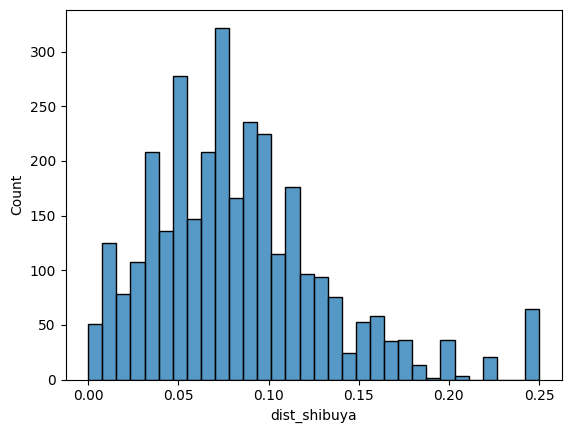

In [420]:
sns.histplot(X["dist_shibuya"])

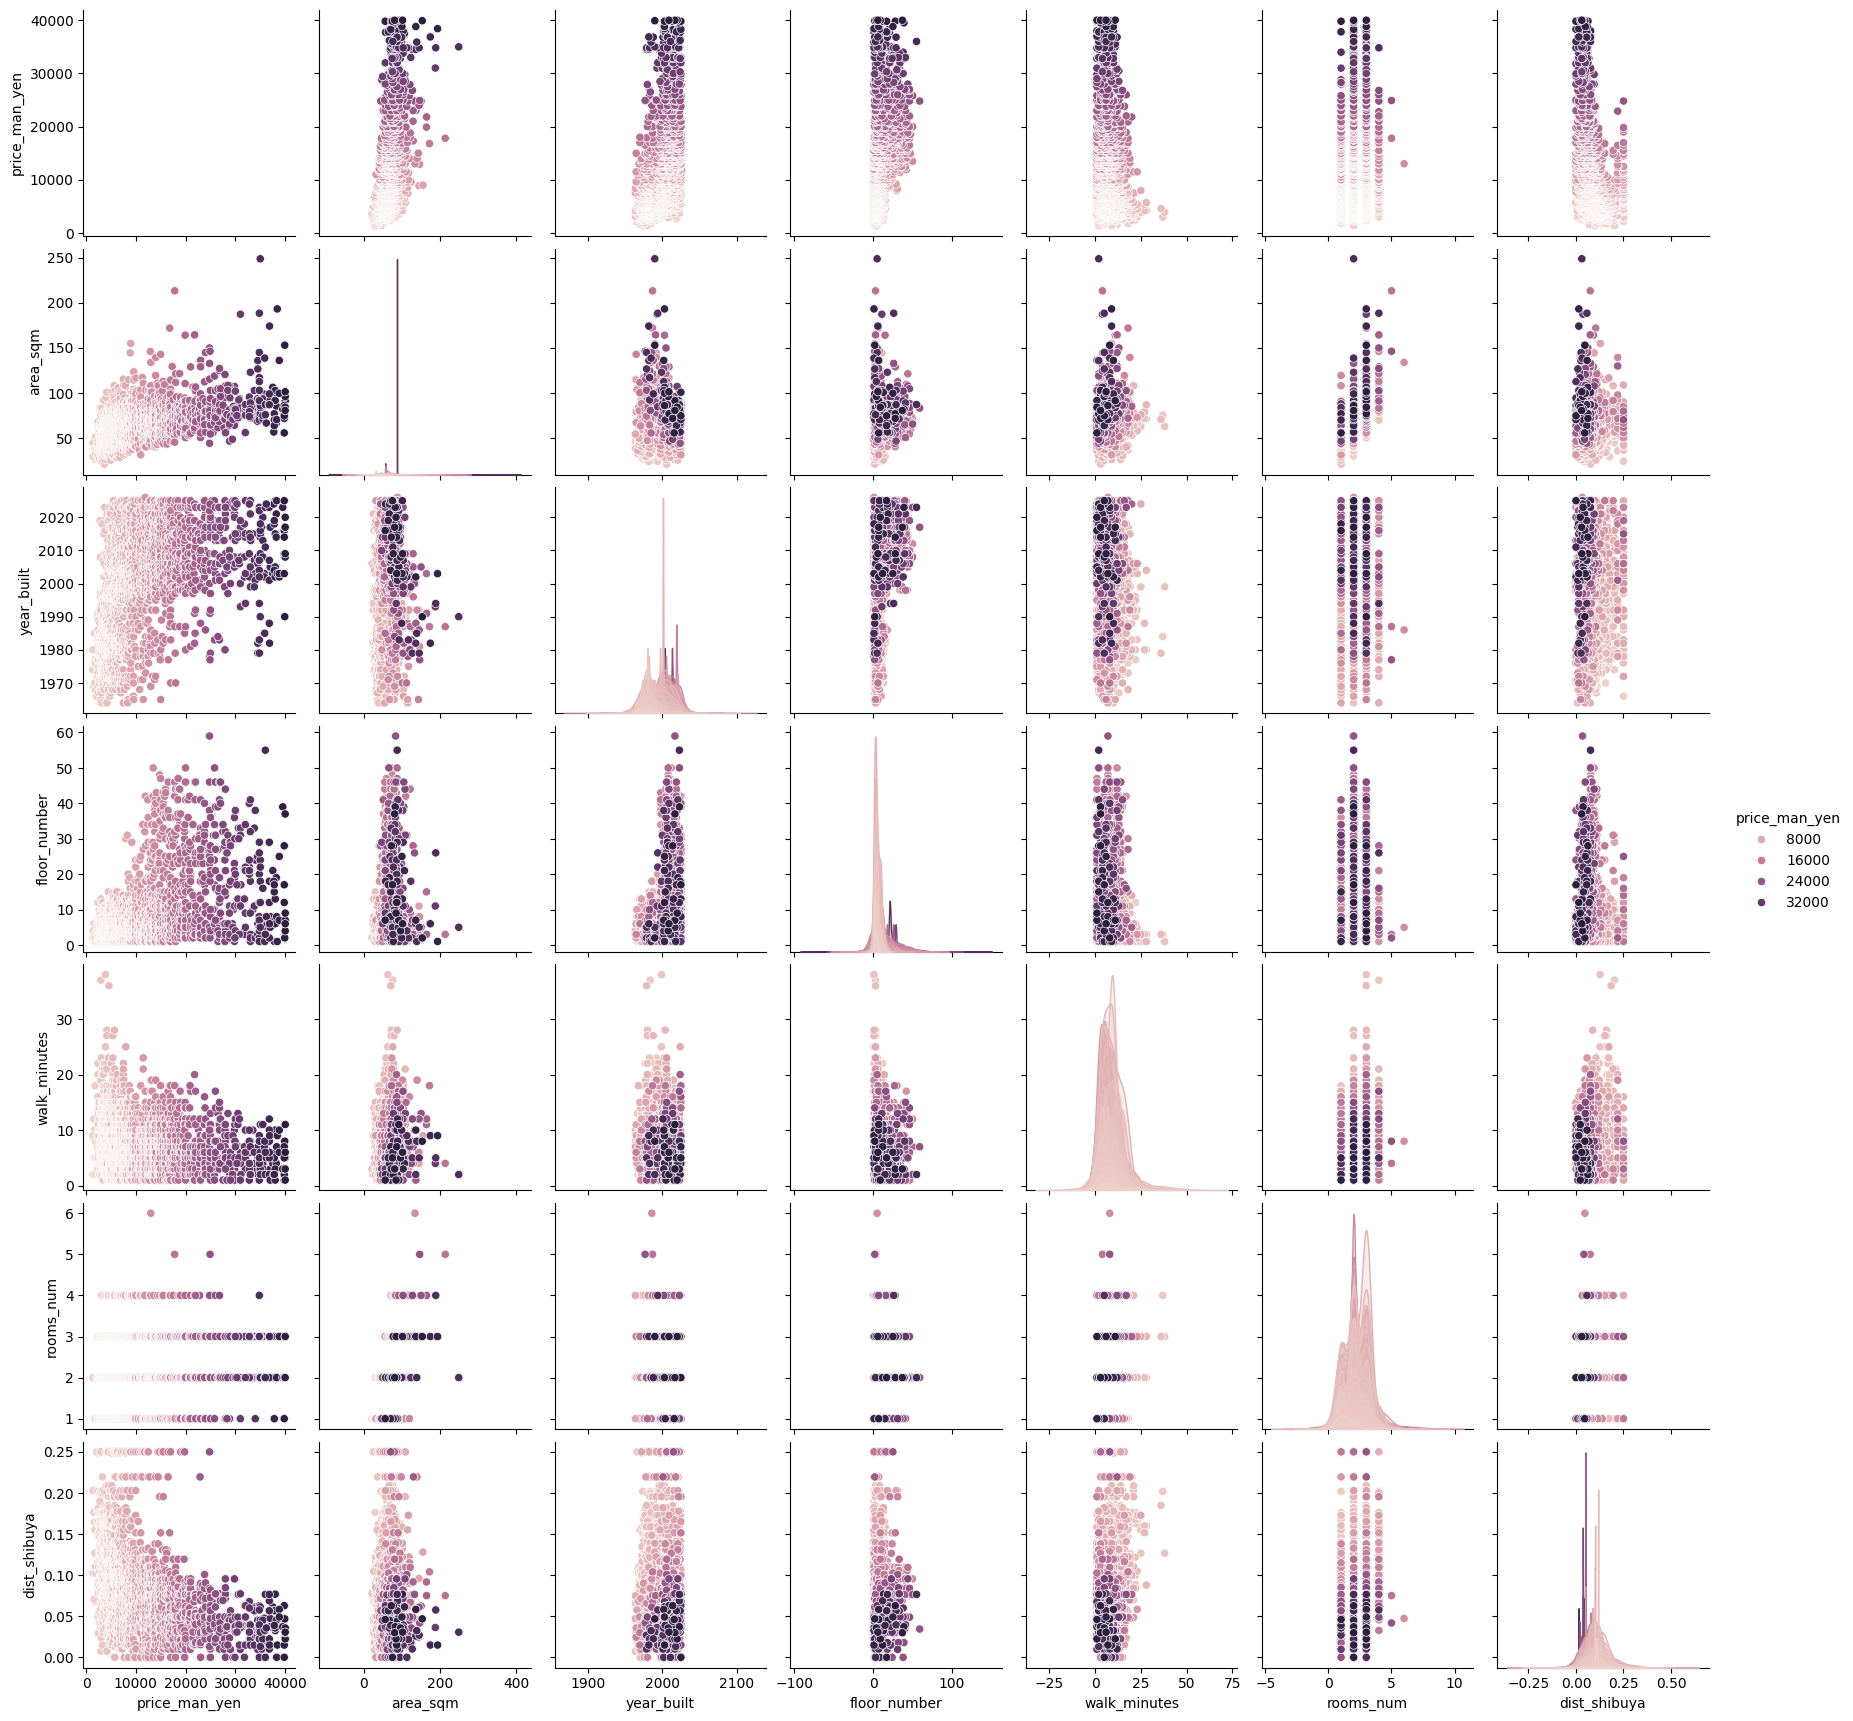

In [421]:
plot_vars = ["price_man_yen", "area_sqm", "year_built", "floor_number", "walk_minutes", "rooms_num", "dist_shibuya"]
sns.pairplot(listing_df_keep, hue="price_man_yen", x_vars=plot_vars, y_vars=plot_vars)

## Kernel Regression

In [478]:
import statsmodels
import sklearn.kernel_ridge

y_actual = np.array(y).ravel()

# model = sklearn.linear_model.Ridge()
model = sklearn.kernel_ridge.KernelRidge(kernel="polynomial")
model.fit(X, y_actual)

y_pred = model.predict(X)

/home/ben/.pyenv/versions/ds2059/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(


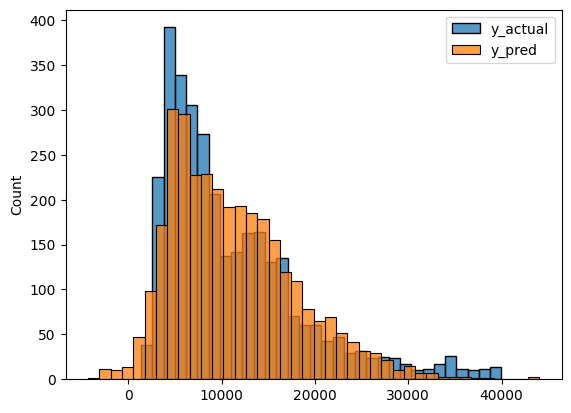

In [479]:
sns.histplot(y_actual, label="y_actual")
sns.histplot(y_pred, label="y_pred")
plt.legend()

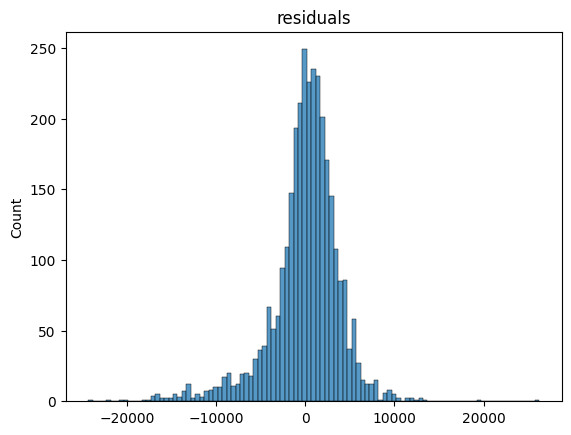

In [480]:
residual = y_pred - y_actual
sns.histplot(residual)
plt.title("residuals");

In [482]:
np.abs(residual).mean()

np.float64(2723.6769331714195)

# Statsmodels

In [426]:
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from statsmodels.compat import lzip
from statsmodels.formula.api import ols
import statsmodels.tools

In [472]:
# drop_idx = [1632, 1664, 1624, 1786, 1766]
drop_idx = []
drop_idx = [3285, 3292, 3289, 3302, 3300, 3298, 3264, 3273, 3150, 3283, 3287, 3284, 3295, 2682, 3296, 3297, 3286, 3290, 3288]

feature_cols = [
  "area_sqm",
  "year_built",
  "floor_number",
  "walk_minutes",
  "dist_shibuya"
  # "rooms_num"
]

X_clean = listing_df[feature_cols].copy().drop(index=drop_idx)
X_clean = statsmodels.tools.tools.add_constant(X_clean)
y_clean = listing_df["price_man_yen"].drop(index=drop_idx)
y_clean = np.log1p(y_clean)

model = sm.OLS(y_clean, X_clean).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          price_man_yen   R-squared:                       0.803
Model:                            OLS   Adj. R-squared:                  0.803
Method:                 Least Squares   F-statistic:                     2680.
Date:                Tue, 10 Mar 2026   Prob (F-statistic):               0.00
Time:                        13:21:29   Log-Likelihood:                -813.54
No. Observations:                3284   AIC:                             1639.
Df Residuals:                    3278   BIC:                             1676.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -30.9505      0.726    -42.637      0.000     -32.374     -29.527
area_sqm         0.0165      0.000     60.202      0.000       0.016       0.017
year_built       0.0198      0.000     54.276      0.000       0.019       0.020
floor_number     0.0127      0.001     19.566      0.000       0.011       0.014
walk_minutes    -0.0265      0.001    -20.795      0.000      -0.029      -0.024
dist_shibuya    -5.3449      0.112    -47.672      0.000      -5.565      -5.125
==============================================================================
Omnibus:                      235.842   Durbin-Watson:                   1.377
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              428.081
Skew:                           0.518   Prob(JB):                     1.11e-93
Kurtosis:                       4.434   Cond. No.                     2.68e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.68e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

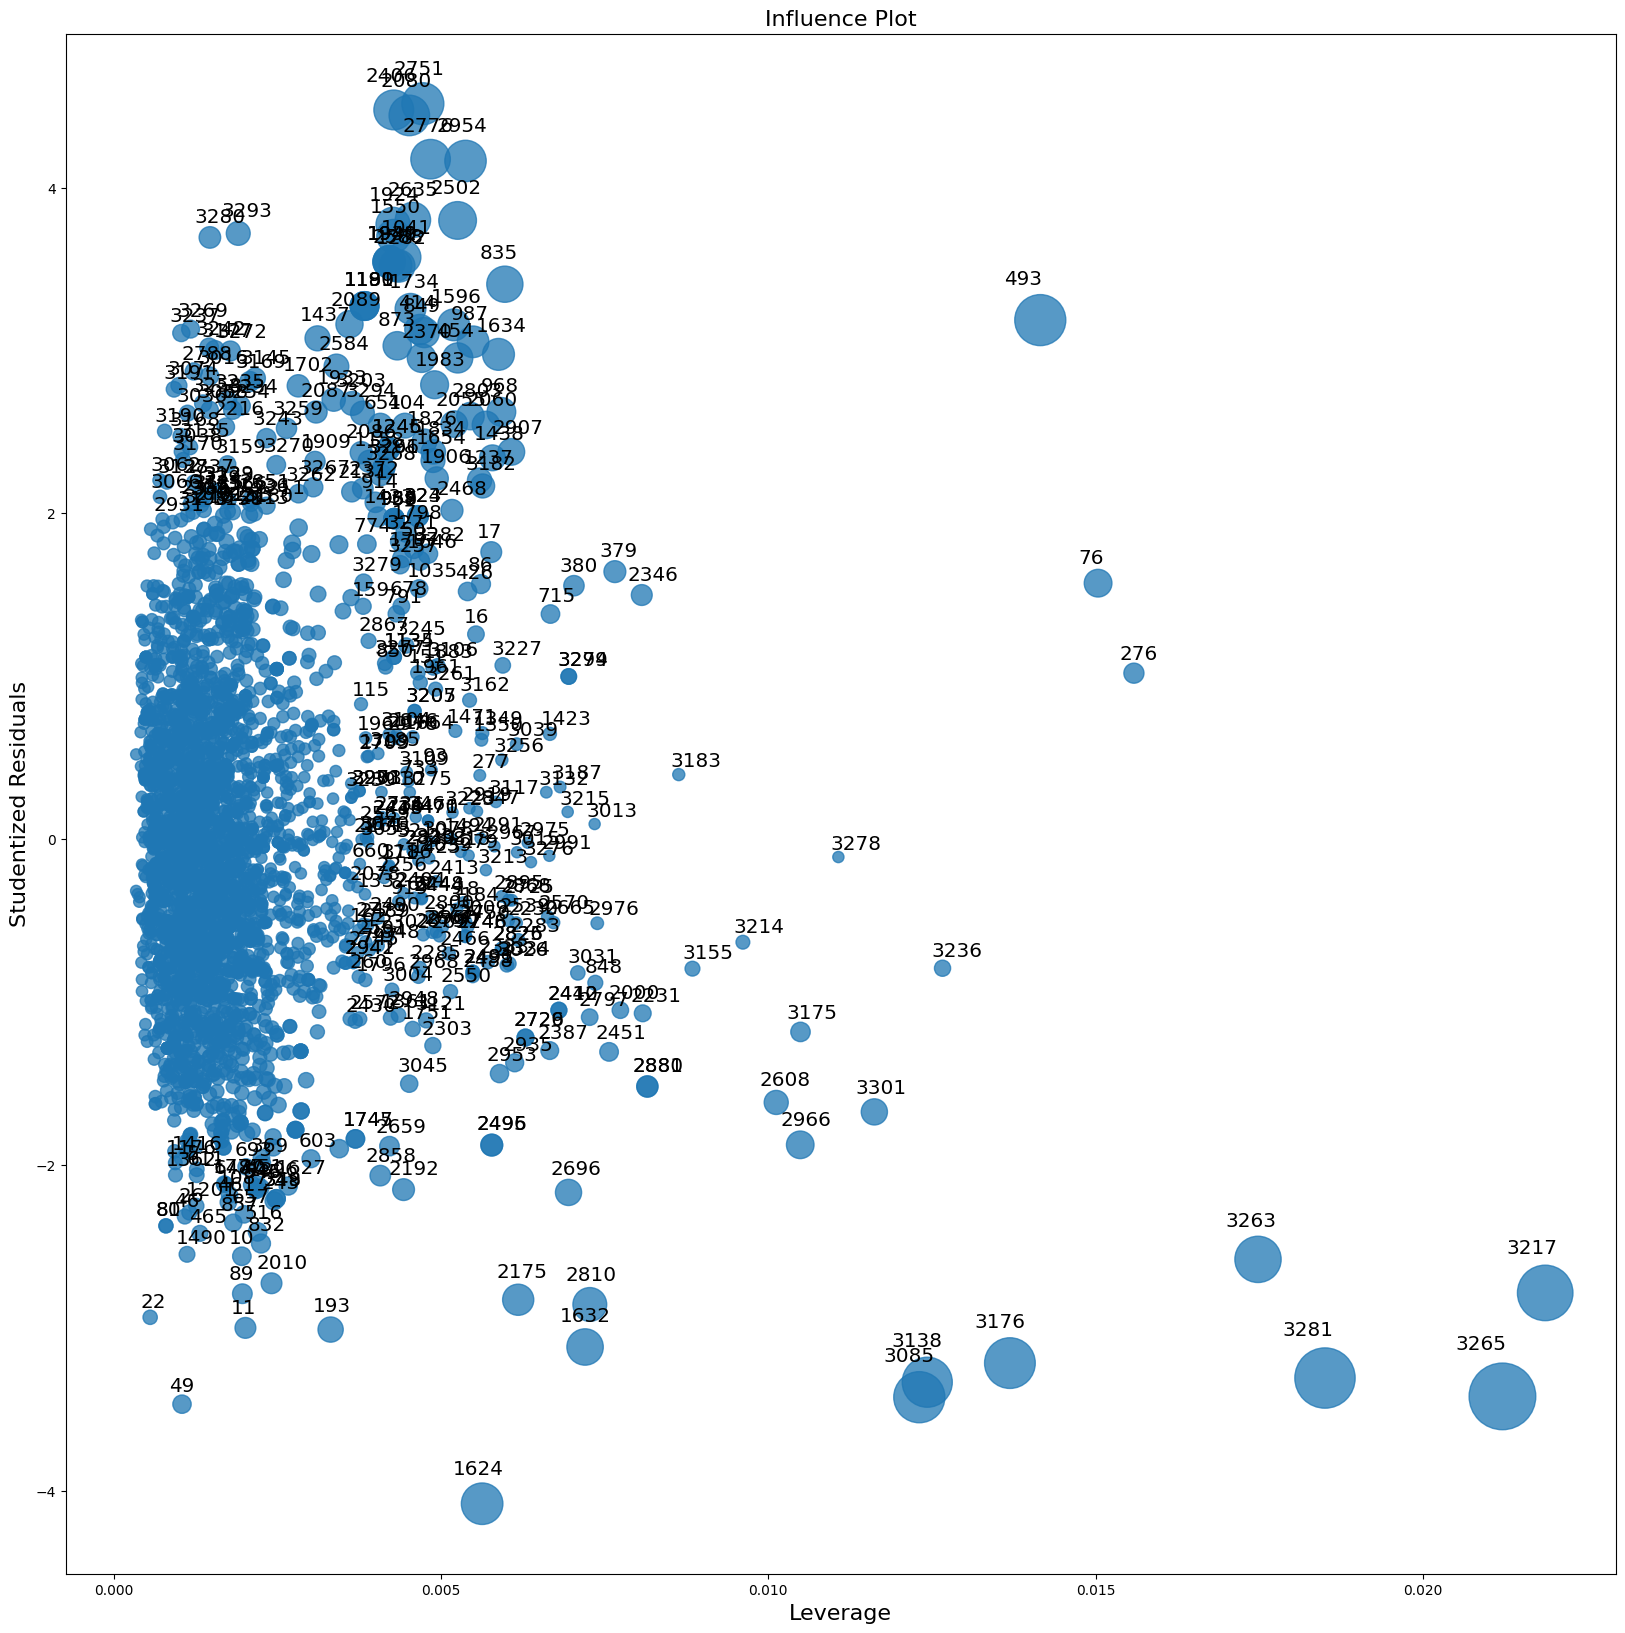

In [473]:
fig = plt.figure(figsize=(20,20))
sm.graphics.influence_plot(model, criterion="cooks", ax=fig.gca());
# fig.tight_layout(pad=1.0)


In [501]:
listing_df.iloc[3217]["url"]

'https://suumo.jp/ms/chuko/tokyo/sc_meguro/nc_79023587/'

In [475]:
y_actual = np.expm1(y_clean)
y_pred = np.expm1(model.predict(X_clean))

residual = y_actual - y_pred.ravel()
np.abs(residual).mean()

/tmp/ipykernel_138857/1874088457.py:4: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  residual = y_actual - y_pred.ravel()


np.float64(3175.851773324748)

<Axes: xlabel='price_man_yen', ylabel='Count'>

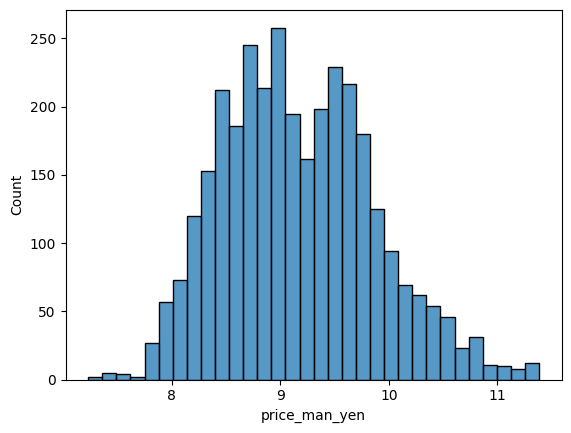

In [476]:
sns.histplot(y_clean)

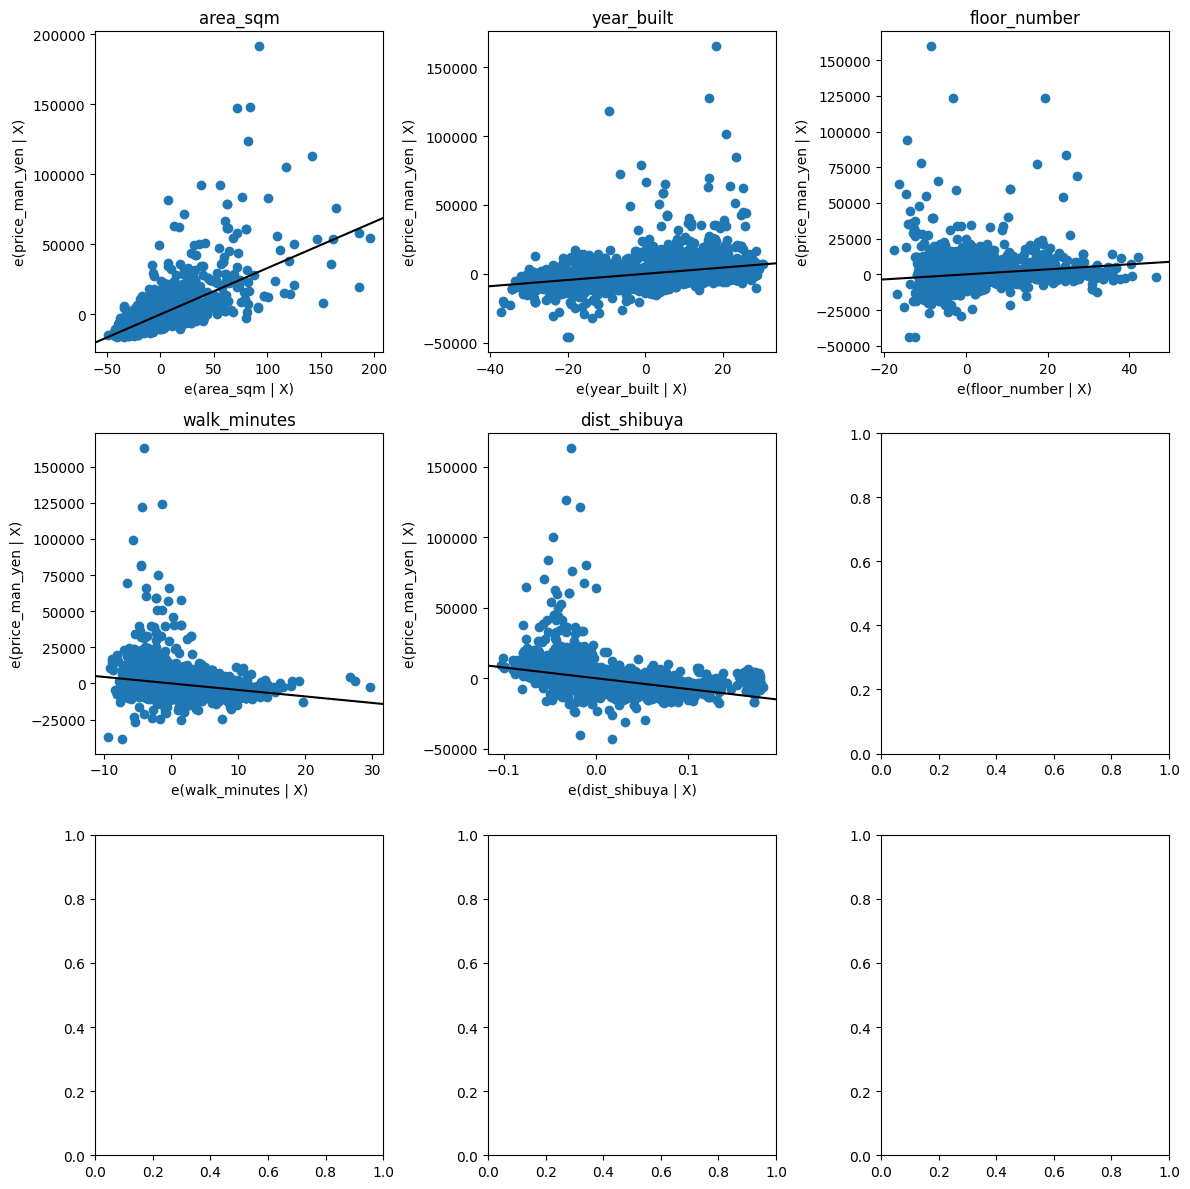

In [477]:
def partial_regression_plot(feature_name: str, ax):
    explanatory = feature_name
    others = [feature for feature in feature_cols if feature != feature_name]

    fig = sm.graphics.plot_partregress(
        "price_man_yen", explanatory, others, data=listing_df,
        obs_labels=False,
        ax=ax
    )
    
    return fig
    
partial_regression_features = feature_cols

n_rows = int(np.ceil(np.sqrt(len(partial_regression_features))))

fig, axs = plt.subplots(n_rows, n_rows, figsize=(4*n_rows, 4*n_rows))

for k,feature_name in enumerate(partial_regression_features):
    r = int(k / n_rows)
    c = k % n_rows

    ax = axs[r,c]
    partial_regression_plot(feature_name ,ax)
    ax.set_title(feature_name)

axs.shape

fig.tight_layout()